In [1]:
pip install transformers


Note: you may need to restart the kernel to use updated packages.


Train Metadata Loaded: (33126, 9)
Test Metadata Loaded: (10982, 5)

Filtered Metadata Size After Validation: 33126

Filtered Metadata Size After Removing Classes with Fewer Than 2 Samples: 33124

Updated Label Mapping: {'unknown': 0, 'nevus': 1, 'melanoma': 2, 'seborrheic keratosis': 3, 'lentigo NOS': 4, 'lichenoid keratosis': 5, 'solar lentigo': 6}

Visualizing some training samples...


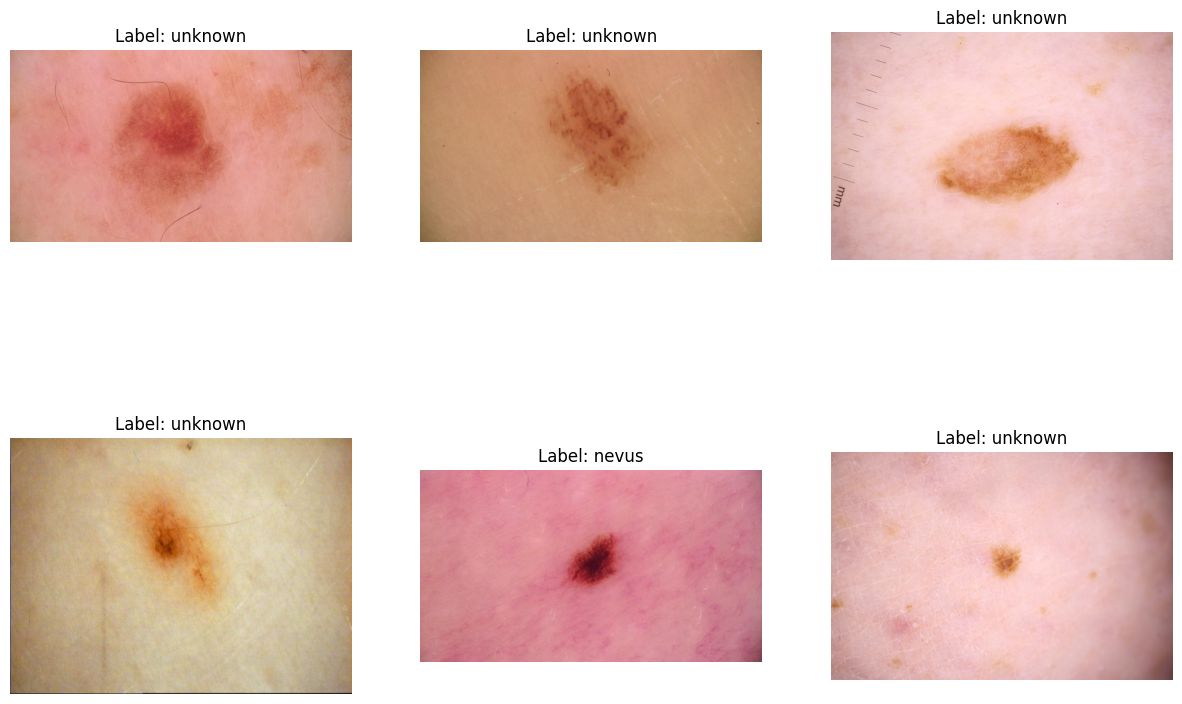


Training Set Size: 26499
Validation Set Size: 6625

Data loaders created successfully.

Sample Batch Shape (Images): torch.Size([32, 3, 224, 224])
Sample Batch Shape (Labels): torch.Size([32])


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Paths
DATASET_PATH = "/kaggle/input/isic-challenge-dataset-2020/ISIC_2020_Dataset"
TRAIN_IMAGES_PATH = os.path.join(DATASET_PATH, "train")
TEST_IMAGES_PATH = os.path.join(DATASET_PATH, "test")
TRAIN_METADATA_PATH = os.path.join(DATASET_PATH, "ISIC_2020_Train_Metadata.csv")
TEST_METADATA_PATH = os.path.join(DATASET_PATH, "ISIC_2020_Test_Metadata.csv")

# Load metadata
train_metadata = pd.read_csv(TRAIN_METADATA_PATH)
test_metadata = pd.read_csv(TEST_METADATA_PATH)

print("Train Metadata Loaded:", train_metadata.shape)
print("Test Metadata Loaded:", test_metadata.shape)

# Add file extension to image names in metadata
train_metadata['image_name_with_ext'] = train_metadata['image_name'] + '.jpg'

# List all image files in the train folder
train_image_files = set(os.listdir(TRAIN_IMAGES_PATH))

# Filter metadata for images that exist in the train folder
filtered_metadata = train_metadata[train_metadata['image_name_with_ext'].isin(train_image_files)]

print("\nFiltered Metadata Size After Validation:", len(filtered_metadata))

# Handle edge cases for labels with fewer than 2 samples
class_counts = filtered_metadata['diagnosis'].value_counts()
valid_classes = class_counts[class_counts > 1].index
filtered_metadata = filtered_metadata[filtered_metadata['diagnosis'].isin(valid_classes)]

print("\nFiltered Metadata Size After Removing Classes with Fewer Than 2 Samples:", len(filtered_metadata))

# Encode labels
label_mapping = {label: idx for idx, label in enumerate(filtered_metadata['diagnosis'].unique())}
filtered_metadata['label'] = filtered_metadata['diagnosis'].map(label_mapping)

print("\nUpdated Label Mapping:", label_mapping)

# Visualize sample images
def visualize_samples(image_dir, metadata, num_samples=6):
    if metadata.empty:
        print("\nNo valid samples to visualize. Metadata is empty.")
        return

    sample_images = metadata.sample(num_samples)
    plt.figure(figsize=(15, 10))
    for idx, (_, row) in enumerate(sample_images.iterrows()):
        img_path = os.path.join(image_dir, row['image_name_with_ext'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, idx + 1)
        plt.imshow(image)
        plt.title(f"Label: {row['diagnosis']}")
        plt.axis("off")
    plt.show()

print("\nVisualizing some training samples...")
visualize_samples(TRAIN_IMAGES_PATH, filtered_metadata)

# Split train and validation sets
if not filtered_metadata.empty:
    train_df, val_df = train_test_split(
        filtered_metadata, test_size=0.2, stratify=filtered_metadata['label'], random_state=42
    )

    print("\nTraining Set Size:", len(train_df))
    print("Validation Set Size:", len(val_df))
else:
    print("\nNo data to split for training and validation.")

# Define dataset class
class ISICDataset(Dataset):
    def __init__(self, metadata, image_dir, transform=None):
        self.metadata = metadata
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_name_with_ext'])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found at {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, label

# Data transformations
data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets and data loaders
if not filtered_metadata.empty:
    train_dataset = ISICDataset(train_df, TRAIN_IMAGES_PATH, transform=data_transforms)
    val_dataset = ISICDataset(val_df, TRAIN_IMAGES_PATH, transform=data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

    print("\nData loaders created successfully.")

    # Test the data loader
    images, labels = next(iter(train_loader))
    print("\nSample Batch Shape (Images):", images.size())
    print("Sample Batch Shape (Labels):", labels.size())
else:
    print("\nNo valid data loaders created due to empty metadata.")



In [3]:
import torch
import torch.nn as nn
from transformers import CLIPModel

# Load the pre-trained CLIP model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")

# Access the vision encoder part of CLIP
vision_model = clip_model.vision_model

# Freeze all layers of the vision model
for param in vision_model.parameters():
    param.requires_grad = False

# Unfreeze the last 4-5 layers
num_layers_to_unfreeze = 5
for layer in vision_model.encoder.layers[-num_layers_to_unfreeze:]:
    for param in layer.parameters():
        param.requires_grad = True

# Verify which layers are frozen and which are unfrozen
frozen_layers = [name for name, param in vision_model.named_parameters() if not param.requires_grad]
unfrozen_layers = [name for name, param in vision_model.named_parameters() if param.requires_grad]

print(f"Frozen Layers: {len(frozen_layers)}")
print(f"Unfrozen Layers: {len(unfrozen_layers)}")
print("\nUnfrozen Layer Names:")
print(unfrozen_layers)

# Now define the attention layer and the classification layer
class AttentionLayer(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(AttentionLayer, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)
        
    def forward(self, x):
        # Assuming x is of shape [seq_len, batch_size, embed_dim]
        return self.attn(x, x, x)[0]

class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(input_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.fc(x)
        return self.softmax(x)

# Define the full model
class CLIPWithAttention(nn.Module):
    def __init__(self, clip_model, num_classes, embed_dim, num_heads):
        super(CLIPWithAttention, self).__init__()
        self.clip_model = clip_model
        self.attention = AttentionLayer(embed_dim, num_heads)
        self.classifier = Classifier(embed_dim, num_classes)

    def forward(self, image):
        # Extract features from the CLIP vision model
        features = self.clip_model.vision_model(image).last_hidden_state  # Features from CLIP

        # Pass the features through the attention layer
        attention_output = self.attention(features)
        
        # Pool the features and pass them to the classifier
        pooled_output = attention_output.mean(dim=1)  # Mean pooling across the sequence
        output = self.classifier(pooled_output)
        return output

# Instantiate the model with required parameters
num_classes = len(label_mapping)  # Use the number of classes in your dataset
embed_dim = vision_model.config.hidden_size  # The dimension of the features
num_heads = 8  # Number of attention heads

model = CLIPWithAttention(clip_model, num_classes, embed_dim, num_heads)

# Print the model architecture
print(model)



config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Frozen Layers: 119
Unfrozen Layers: 80

Unfrozen Layer Names:
['encoder.layers.7.self_attn.k_proj.weight', 'encoder.layers.7.self_attn.k_proj.bias', 'encoder.layers.7.self_attn.v_proj.weight', 'encoder.layers.7.self_attn.v_proj.bias', 'encoder.layers.7.self_attn.q_proj.weight', 'encoder.layers.7.self_attn.q_proj.bias', 'encoder.layers.7.self_attn.out_proj.weight', 'encoder.layers.7.self_attn.out_proj.bias', 'encoder.layers.7.layer_norm1.weight', 'encoder.layers.7.layer_norm1.bias', 'encoder.layers.7.mlp.fc1.weight', 'encoder.layers.7.mlp.fc1.bias', 'encoder.layers.7.mlp.fc2.weight', 'encoder.layers.7.mlp.fc2.bias', 'encoder.layers.7.layer_norm2.weight', 'encoder.layers.7.layer_norm2.bias', 'encoder.layers.8.self_attn.k_proj.weight', 'encoder.layers.8.self_attn.k_proj.bias', 'encoder.layers.8.self_attn.v_proj.weight', 'encoder.layers.8.self_attn.v_proj.bias', 'encoder.layers.8.self_attn.q_proj.weight', 'encoder.layers.8.self_attn.q_proj.bias', 'encoder.layers.8.self_attn.out_proj.weight

In [4]:
# Freeze all layers in the CLIP vision model initially
for param in vision_model.parameters():
    param.requires_grad = False

# Unfreeze the last 4-5 layers of the vision model's transformer
num_layers_to_unfreeze = 5
for layer in vision_model.encoder.layers[-num_layers_to_unfreeze:]:
    for param in layer.parameters():
        param.requires_grad = True

# Confirm which layers are unfrozen
for idx, layer in enumerate(vision_model.encoder.layers):
    layer_status = any(param.requires_grad for param in layer.parameters())
    print(f"Layer {idx + 1}: {'Unfrozen' if layer_status else 'Frozen'}")


Layer 1: Frozen
Layer 2: Frozen
Layer 3: Frozen
Layer 4: Frozen
Layer 5: Frozen
Layer 6: Frozen
Layer 7: Frozen
Layer 8: Unfrozen
Layer 9: Unfrozen
Layer 10: Unfrozen
Layer 11: Unfrozen
Layer 12: Unfrozen


In [5]:
import torch
import torch.nn as nn

# Define the Attention Layer
class AttentionLayer(nn.Module):
    def __init__(self, embed_dim, num_heads):
        """
        Multi-head Attention Layer
        Args:
            embed_dim: Dimension of the input embeddings
            num_heads: Number of attention heads
        """
        super(AttentionLayer, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """
        Forward pass of the Attention Layer
        Args:
            x: Input feature tensor of shape [batch_size, seq_len, embed_dim]
        Returns:
            Output feature tensor of shape [batch_size, seq_len, embed_dim]
        """
        # Apply multi-head attention
        attn_output, _ = self.attn(x, x, x)
        # Add residual connection and apply layer normalization
        return self.layer_norm(x + attn_output)

# Example Usage
# Assuming vision_model.encoder.layers[-1].output provides embeddings of shape [batch_size, seq_len, embed_dim]
batch_size = 8
seq_len = 197  # Typical for CLIP Vision Transformer
embed_dim = 768
num_heads = 8

# Dummy input feature map from CLIP Vision Transformer
input_features = torch.rand(batch_size, seq_len, embed_dim)

# Initialize the attention layer
attention_layer = AttentionLayer(embed_dim=embed_dim, num_heads=num_heads)

# Forward pass through the attention layer
attention_output = attention_layer(input_features)
print("Output shape after attention:", attention_output.shape)


Output shape after attention: torch.Size([8, 197, 768])


In [6]:
import torch
import torch.nn as nn

# Define the Classification Layer
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        """
        Classification layer with a fully connected layer and softmax activation.
        Args:
            input_dim: Dimension of the input features (embed_dim from the attention layer)
            num_classes: Number of target classes
        """
        super(Classifier, self).__init__()
        self.fc = nn.Linear(input_dim, num_classes)  # Fully connected layer
        self.softmax = nn.Softmax(dim=1)            # Softmax activation

    def forward(self, x):
        """
        Forward pass of the classifier
        Args:
            x: Input feature tensor of shape [batch_size, input_dim]
        Returns:
            Class probabilities of shape [batch_size, num_classes]
        """
        x = self.fc(x)         # Linear transformation
        return self.softmax(x) # Apply softmax activation

# Example Usage
batch_size = 8
input_dim = 768  # Same as the embed_dim of the Attention Layer
num_classes = 7  # Example: 7 classes for skin classification (adjust as needed)

# Dummy pooled features from the Attention Layer (mean pooling)
pooled_features = torch.rand(batch_size, input_dim)  # Shape: [batch_size, input_dim]

# Initialize the classifier
classifier = Classifier(input_dim=input_dim, num_classes=num_classes)

# Forward pass through the classifier
class_probs = classifier(pooled_features)
print("Class probabilities shape:", class_probs.shape)



Class probabilities shape: torch.Size([8, 7])


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        """
        Contrastive loss for contrastive learning.
        Args:
            temperature: A scaling factor for cosine similarity (default: 0.1).
        """
        super(ContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        Compute contrastive loss.
        Args:
            features: Normalized feature embeddings of shape [batch_size, embed_dim].
            labels: Ground truth labels of shape [batch_size].
        Returns:
            Loss: A scalar contrastive loss value.
        """
        # Normalize features to have unit norm
        features = F.normalize(features, dim=1)  # Shape: [batch_size, embed_dim]

        # Compute cosine similarity matrix
        similarity_matrix = torch.matmul(features, features.T)  # Shape: [batch_size, batch_size]
        similarity_matrix /= self.temperature                  # Scale by temperature

        # Mask diagonal (self-similarity)
        batch_size = features.shape[0]
        mask = torch.eye(batch_size, dtype=torch.bool, device=features.device)
        similarity_matrix.masked_fill_(mask, -float("inf"))

        # Create labels for the contrastive task
        labels = torch.arange(batch_size, device=features.device)

        # Compute cross-entropy loss
        loss = F.cross_entropy(similarity_matrix, labels)
        return loss

# Example Usage
batch_size = 8
embed_dim = 768  # Same as the output dimension of the attention layer
temperature = 0.1  # Increased temperature to prevent overflow

# Dummy embeddings from the attention layer
features = torch.rand(batch_size, embed_dim)  # Shape: [batch_size, embed_dim]

# Dummy ground truth labels
labels = torch.arange(batch_size)  # Assuming labels are in range [0, batch_size-1]

# Initialize contrastive loss
contrastive_loss = ContrastiveLoss(temperature=temperature)

# Compute the loss
loss = contrastive_loss(features, labels)
print(f"Contrastive Loss: {loss.item()}")


Contrastive Loss: inf


In [8]:
import torch
import torch.nn as nn

class CLIPWithAttention(nn.Module):
    def __init__(self, clip_model, embed_dim, num_heads, num_classes):
        """
        Combines the CLIP vision encoder, an attention layer, and a classifier.
        Args:
            clip_model: Pre-trained CLIP model.
            embed_dim: Dimensionality of the embeddings (e.g., 768 for ViT-B/16).
            num_heads: Number of heads for the attention layer.
            num_classes: Number of output classes for classification.
        """
        super(CLIPWithAttention, self).__init__()
        self.clip_model = clip_model  # Pre-trained CLIP model
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)  # Attention layer
        self.classifier = nn.Linear(embed_dim, num_classes)  # Classification head
        self.softmax = nn.Softmax(dim=1)  # Softmax for class probabilities

    def forward(self, images):
        """
        Forward pass for the model.
        Args:
            images: Input images of shape [batch_size, 3, H, W].
        Returns:
            Predicted class probabilities of shape [batch_size, num_classes].
        """
        # Step 1: Extract features using the CLIP vision model
        vision_output = self.clip_model.vision_model(images)
        features = vision_output.last_hidden_state  # Shape: [batch_size, seq_len, embed_dim]

        # Transpose for attention (required shape: [seq_len, batch_size, embed_dim])
        features = features.permute(1, 0, 2)

        # Step 2: Apply attention
        attn_output, _ = self.attention(features, features, features)  # Attention output

        # Step 3: Pooling (mean across the sequence length)
        pooled_features = attn_output.mean(dim=0)  # Shape: [batch_size, embed_dim]

        # Step 4: Pass through classifier
        logits = self.classifier(pooled_features)  # Shape: [batch_size, num_classes]

        # Step 5: Apply softmax
        probabilities = self.softmax(logits)  # Shape: [batch_size, num_classes]

        return probabilities


In [9]:
import torch
import torch.nn as nn

# Function to evaluate the model on validation/test data
def evaluate_model(model, data_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    eval_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculations for evaluation
        for images, labels in data_loader:
            # Move images and labels to the device
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)
            eval_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    # Calculate average loss and accuracy
    eval_loss /= len(data_loader)
    accuracy = correct / total
    return eval_loss, accuracy, predicted



In [10]:
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, device):
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            
            # Ensure outputs and labels are in the correct format
            print(f"Outputs shape: {outputs.shape}, Labels shape: {labels.shape}")
            print(f"Labels: {labels}")  # Check label values to make sure they're valid
            
            # Compute loss
            loss = criterion(outputs, labels)
            train_loss += loss.item()
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Accuracy calculation
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # Print loss and accuracy per epoch
        epoch_loss = train_loss / len(train_loader)
        epoch_accuracy = correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")
        
        # Optionally evaluate the model on the validation set
        model.eval()
        val_loss, val_accuracy, _ = evaluate_model(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Example usage
if __name__ == "__main__":
    # Set hyperparameters and device
    num_epochs = 10
    batch_size = 32
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Assuming train_loader and val_loader are prepared
    model = CLIPWithAttention(clip_model, embed_dim, num_heads, num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.CrossEntropyLoss()

    # Train the model
    train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, device)


Outputs shape: torch.Size([32, 7]), Labels shape: torch.Size([32])
Labels: tensor([0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0], device='cuda:0')
Outputs shape: torch.Size([32, 7]), Labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5,
        0, 0, 1, 0, 1, 0, 0, 0], device='cuda:0')
Outputs shape: torch.Size([32, 7]), Labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 1, 0, 1], device='cuda:0')
Outputs shape: torch.Size([32, 7]), Labels shape: torch.Size([32])
Labels: tensor([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0], device='cuda:0')
Outputs shape: torch.Size([32, 7]), Labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 0,